# Polymarket BTC — Calibration Study

This notebook evaluates how well Polymarket's implied distributions for daily
BTC price-range markets are calibrated, and benchmarks them against standard
forecasting models:

* **Rolling historical volatility** (30-day, 90-day)
* **GARCH(1,1)** fitted on daily Binance BTC/USDT returns
* **HAR-RV** (Heterogeneous AutoRegressive Realized Variance)
* **Deribit ATM implied volatility** (option-market benchmark)
* **Naïve random-walk** (long-run average vol)

**Evaluation metrics:** log-score, CRPS, Brier score per band.
**Statistical tests:** Diebold–Mariano to compare predictive accuracy.
**Edge cases:** days when BTC resolved in the lower or upper tail bands.

The Polymarket oracle uses the Binance BTC/USDT price; Binance hourly close
data is fetched from the REST API and used as the reference price series.


## 1. Imports & Setup

In [1]:
import os
import time
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import requests
from scipy.stats import norm, kstest
from scipy.optimize import minimize, brentq
from scipy.special import owens_t
from arch import arch_model
import statsmodels.api as sm
from tqdm.auto import tqdm
from dotenv import load_dotenv

load_dotenv(override=False)

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')
plt.rcParams.update({'figure.dpi': 100})

BINANCE_API_KEY = os.getenv('BINANCE_API_KEY', '')
UPPER_SENTINEL = 1_000_000


## 2. Load Polymarket Data

In [2]:
prices    = pd.read_parquet('data/prices_extended.parquet')
trades    = pd.read_parquet('data/trades_extended.parquet')
summaries = pd.read_parquet('data/market_summary.parquet')

# ── Yes-only panel ────────────────────────────────────────────────────────────
yes = prices[prices['outcome_label'] == 'Yes'].copy()
yes['band_mid']    = (yes['lower_price'] + yes['upper_price']) / 2.0
yes['target_date'] = pd.to_datetime(yes['target_date'], utc=True).dt.normalize()
yes['timestamp']   = pd.to_datetime(yes['timestamp'], utc=True)
yes['market_end_date'] = pd.to_datetime(yes['market_end_date'], utc=True)
yes['minutes_to_resolution'] = (
    (yes['market_end_date'] - yes['timestamp']).dt.total_seconds() / 60.0
)
# Fix edge-band midpoints (proxy only – not used in centred analyses)
elo = yes['lower_price'] == 0
ehi = yes['upper_price'] >= UPPER_SENTINEL
yes.loc[elo, 'band_mid'] = yes.loc[elo, 'upper_price'] / 2
yes.loc[ehi, 'band_mid'] = yes.loc[ehi, 'lower_price'] * 1.5

# 15-minute resampled panel (speeds up heatmaps / snapshot averaging)
yes_15m          = yes.copy()
yes_15m['ttr_h'] = yes_15m['minutes_to_resolution'] / 60.0
yes_15m['ttr_bin'] = (yes_15m['ttr_h'] / 0.25).round() * 0.25

# ── Settlement info ────────────────────────────────────────────────────────────
settle = (yes.groupby(['target_date', 'price_band_label'], as_index=False)
             .agg(lower_price =('lower_price',  'first'),
                  upper_price =('upper_price',  'first'),
                  band_mid    =('band_mid',      'first'),
                  outcome_price=('outcome_price','last')))
winners = settle[settle['outcome_price'] == 1]

# Finite bands only (for centred analyses)
settled_band = (
    winners.loc[(winners['lower_price'] > 0) & (winners['upper_price'] < UPPER_SENTINEL)]
           .set_index('target_date')
           [['price_band_label','lower_price','upper_price','band_mid']]
           .rename(columns={'price_band_label':'settled_band',
                            'lower_price':'settled_lower',
                            'upper_price':'settled_upper',
                            'band_mid':'settled_mid'}))

# All winners including edge bands (needed for model evaluation)
settled_all = (
    winners.set_index('target_date')
           [['price_band_label','lower_price','upper_price','band_mid']]
           .rename(columns={'price_band_label':'settled_band',
                            'lower_price':'settled_lower',
                            'upper_price':'settled_upper',
                            'band_mid':'settled_mid'}))

# Edge-case catalogues
edge_lower_days = set(winners.loc[winners['lower_price'] == 0, 'target_date'])
edge_upper_days = set(winners.loc[winners['upper_price'] >= UPPER_SENTINEL, 'target_date'])

print(f"Resolution days total   : {winners['target_date'].nunique()}")
print(f"Finite band wins        : {len(settled_band)}")
print(f"Lower tail wins (<min)  : {len(edge_lower_days)}")
print(f"Upper tail wins (>max)  : {len(edge_upper_days)}")


Resolution days total   : 80
Finite band wins        : 71
Lower tail wins (<min)  : 9
Upper tail wins (>max)  : 0


In [3]:
BUCKET_EDGES_FINE     = [0, 4, 8, 12, 16, 20, 24]
BUCKET_EDGES_EXTENDED = [0, 4, 8, 12, 16, 20, 24, 48, 72, 120, 168]

lookbacks_fine     = [(lo, hi, f'{lo}-{hi} h')
                      for lo, hi in zip(BUCKET_EDGES_FINE[:-1],     BUCKET_EDGES_FINE[1:])]
lookbacks_extended = [(lo, hi, f'{lo}-{hi} h')
                      for lo, hi in zip(BUCKET_EDGES_EXTENDED[:-1], BUCKET_EDGES_EXTENDED[1:])]

# Per-(date, ttr_bin, band) average Yes price used by snapshot_in_window
snap_all = (yes_15m.groupby(['target_date', 'ttr_bin', 'lower_price', 'upper_price'],
                             as_index=False)['price'].mean())

def snapshot_in_window(lo_h, hi_h, src=None):
    df = snap_all if src is None else src
    g  = df[(df['ttr_bin'] >= lo_h) & (df['ttr_bin'] < hi_h)]
    if g.empty:
        return g.iloc[0:0].copy()
    return (g.groupby(['target_date', 'lower_price', 'upper_price'], as_index=False)
              .agg(price=('price', 'mean'), n=('price', 'size')))


## 3. Binance BTC/USDT Hourly Reference Data

Polymarket uses the **Binance BTC/USDT spot price** as the oracle for market
resolution.  We fetch hourly close data from the Binance public klines endpoint,
which does not require authentication (the API key from `.env` raises the rate
limit only).  Data is cached locally to `data/binance_hourly_btcusdt.parquet`.

From the hourly series we derive:
* **Daily log-returns** (close-to-close)
* **Daily realised variance** (sum of squared hourly log-returns per calendar day)
* **Binance spot price at each Polymarket snapshot** (used as $S_t$ in all models)


In [4]:
BINANCE_CACHE = Path('data/binance_hourly_btcusdt.parquet')
BINANCE_URL   = 'https://api.binance.com/api/v3/klines'

def fetch_binance_hourly(start_dt, end_dt, symbol='BTCUSDT', interval='1h', api_key=''):
    headers = {'X-MBX-APIKEY': api_key} if api_key else {}
    start_ms = int(start_dt.timestamp() * 1000)
    end_ms   = int(end_dt.timestamp()   * 1000)
    all_klines = []
    current = start_ms
    while current < end_ms:
        params = dict(symbol=symbol, interval=interval,
                      startTime=current, endTime=end_ms, limit=1000)
        r = requests.get(BINANCE_URL, params=params, headers=headers, timeout=30)
        r.raise_for_status()
        batch = r.json()
        if not batch:
            break
        all_klines.extend(batch)
        current = int(batch[-1][0]) + 1
        if len(batch) < 1000:
            break
        time.sleep(0.12)
    if not all_klines:
        return pd.DataFrame()
    cols = ['open_time','open','high','low','close','volume',
            'close_time','quote_vol','n_trades','tb_base','tb_quote','_']
    df = pd.DataFrame(all_klines, columns=cols)
    df['timestamp'] = pd.to_datetime(df['open_time'].astype(np.int64), unit='ms', utc=True)
    for c in ['open','high','low','close','volume']:
        df[c] = df[c].astype(float)
    return df[['timestamp','open','high','low','close','volume']].reset_index(drop=True)

if BINANCE_CACHE.exists():
    binance = pd.read_parquet(BINANCE_CACHE)
    print(f"Loaded cached Binance data: {len(binance):,} rows  "
          f"({binance['timestamp'].min().date()} → {binance['timestamp'].max().date()})")
else:
    start_dt = pd.Timestamp('2024-09-01', tz='UTC')
    end_dt   = pd.Timestamp('2026-01-25', tz='UTC')
    print(f"Fetching Binance hourly BTC/USDT {start_dt.date()} → {end_dt.date()} …")
    binance = fetch_binance_hourly(start_dt, end_dt, api_key=BINANCE_API_KEY)
    binance.to_parquet(BINANCE_CACHE, index=False)
    print(f"Fetched and cached {len(binance):,} rows")

binance = binance.sort_values('timestamp').drop_duplicates('timestamp').reset_index(drop=True)
binance['log_ret'] = np.log(binance['close'] / binance['close'].shift(1))
print(f"Price range: {binance['close'].min():.0f} – {binance['close'].max():.0f}  "
      f"| hourly log-ret std = {binance['log_ret'].std()*100:.3f}%")


Loaded cached Binance data: 12,265 rows  (2024-09-01 → 2026-01-25)
Price range: 52888 – 126011  | hourly log-ret std = 0.483%


In [5]:
# Daily close, log-return, and realised variance
binance['date'] = binance['timestamp'].dt.normalize()

daily = (binance.groupby('date')
                .agg(close    =('close',   'last'),
                     rv_daily =('log_ret', lambda r: float((r**2).sum())))
                .reset_index())
daily['log_ret_d'] = np.log(daily['close'] / daily['close'].shift(1))
daily = daily.sort_values('date').reset_index(drop=True)
# Annualised vol proxy: rv_daily is in (daily fraction)^2 units; ann. = rv * 252
daily['ann_vol'] = np.sqrt(daily['rv_daily'] * 252)

# Binance spot at each Polymarket snapshot time:
# For TTR bucket midpoint ttr_mid_h before resolution, we need the close
# of the hourly candle that opened ttr_mid_h hours before midnight UTC.
def get_spot_at_ttr(target_date, ttr_mid_h):
    snap_time = target_date - pd.Timedelta(hours=ttr_mid_h)
    snap_time = snap_time.floor('h')
    row = binance.loc[binance['timestamp'] == snap_time, 'close']
    if not row.empty:
        return float(row.iloc[0])
    idx = (binance['timestamp'] - snap_time).abs().idxmin()
    return float(binance.loc[idx, 'close'])

# Quick sanity: resolution spot prices
res_spots = {d: get_spot_at_ttr(d, 0.5) for d in yes['target_date'].unique()}
print(f"Resolution spot prices retrieved for {len(res_spots)} days")
sample = dict(list(res_spots.items())[:4])
print({str(k.date()): round(v) for k, v in sample.items()})


Resolution spot prices retrieved for 81 days
{'2025-11-01': 109608, '2025-11-02': 110098, '2025-11-03': 110541, '2025-11-04': 106583}


## 3b. Deribit ATM Implied Volatility

For each resolution date we extract the **at-the-money (ATM) implied volatility**
from Deribit BTC option trades in the 24 h window before resolution.  We use the
shortest-dated expiry available and restrict to options with
$|\ln(K/S)| < 10\%$ to stay near the money.

The resulting IV is used as the *option-implied* benchmark forecast.


In [6]:
deribit = pd.read_parquet('data/deribit_full.parquet')
deribit['timestamp'] = pd.to_datetime(deribit['timestamp'], utc=True)

def _parse_expiry(name):
    parts = name.split('-')
    if len(parts) < 4:
        return pd.NaT, np.nan, None
    try:
        expiry = pd.to_datetime(parts[1], format='%d%b%y', utc=True)
    except Exception:
        return pd.NaT, np.nan, None
    try:
        strike = float(parts[2])
    except Exception:
        return pd.NaT, np.nan, None
    return expiry, strike, parts[3]

parsed = deribit['instrument_name'].apply(_parse_expiry)
deribit[['expiry','strike','opt_type']] = pd.DataFrame(parsed.tolist(), index=deribit.index)
deribit = deribit.dropna(subset=['expiry','strike','opt_type']).copy()
deribit['expiry'] = pd.to_datetime(deribit['expiry'], utc=True)

deribit_atm_iv = {}
for target_date in yes['target_date'].unique():
    t_end   = target_date
    t_start = target_date - pd.Timedelta(hours=25)
    local = deribit[(deribit['timestamp'] >= t_start) & (deribit['timestamp'] < t_end)]
    if local.empty:
        continue
    # Closest-to-target expiry
    expiries = local['expiry'].unique()
    closest  = min(expiries, key=lambda e: abs((e - target_date).total_seconds()))
    local = local[local['expiry'] == closest].copy()
    local = local[(local['index_price'] > 0) & (local['strike'] > 0)]
    local['moneyness'] = np.abs(np.log(local['strike'] / local['index_price']))
    atm = local[local['moneyness'] < 0.10]
    iv_vals = atm['iv'].dropna()
    iv_vals = iv_vals[iv_vals > 0]
    if len(iv_vals) >= 3:
        deribit_atm_iv[target_date] = float(iv_vals.median()) / 100.0  # % → decimal

print(f"Deribit ATM IV available for {len(deribit_atm_iv)} / {yes['target_date'].nunique()} resolution days")
sample_iv = {str(k.date()): round(v * 100, 1)
             for k, v in sorted(deribit_atm_iv.items())[:6]}
print("Sample ATM IV (%):", sample_iv)


Deribit ATM IV available for 79 / 81 resolution days
Sample ATM IV (%): {'2025-11-02': 22.6, '2025-11-03': 45.0, '2025-11-04': 45.1, '2025-11-05': 59.1, '2025-11-06': 54.1, '2025-11-07': 53.4}


## 4. Key Figures (reproduced from `polymarket_analysis.ipynb`)

These figures are reproduced here as context for the calibration comparison
that follows.


### 4a. Aggregate probability heatmap (centred on resolved band)

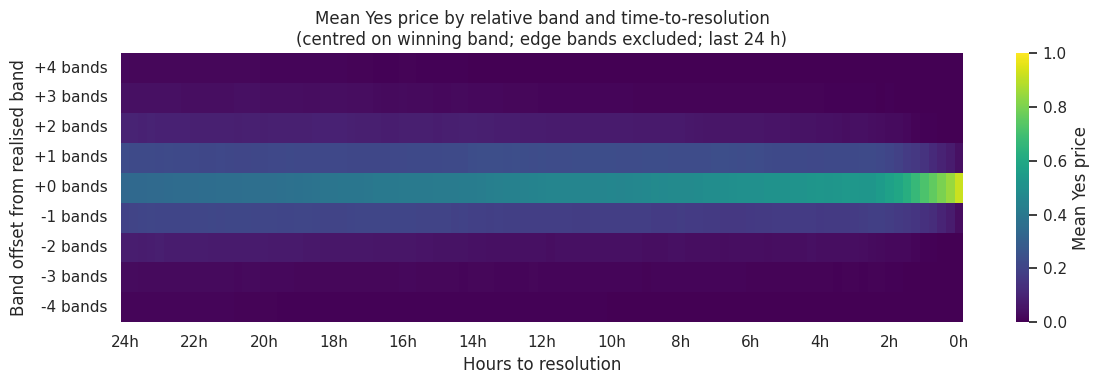

In [7]:
yes_15m_finite = yes_15m[
    (yes_15m['lower_price'] > 0) & (yes_15m['upper_price'] < UPPER_SENTINEL)
].copy()

resolved_yes = yes_15m_finite.merge(
    settled_band[['settled_mid']], left_on='target_date', right_index=True, how='inner')
resolved_yes['rel_band'] = (
    (resolved_yes['band_mid'] - resolved_yes['settled_mid']) / 2000).round().astype(int)

agg_heat = (resolved_yes.groupby(['rel_band', 'ttr_bin'])['price']
                        .mean().unstack('ttr_bin'))
agg_heat = agg_heat.sort_index()
agg_heat = agg_heat[sorted(agg_heat.columns, reverse=True)]
agg_heat = agg_heat.loc[(agg_heat.index >= -4) & (agg_heat.index <= 4)]
agg_heat = agg_heat.loc[:, agg_heat.columns <= 24]

fig, ax = plt.subplots(figsize=(12, 4))
sns.heatmap(agg_heat.values, ax=ax, cmap='viridis', vmin=0, vmax=1,
            cbar_kws={'label': 'Mean Yes price'})
cols = agg_heat.columns.to_numpy()
step = max(1, len(cols) // 12)
ax.set_xticks(np.arange(0, len(cols), step) + 0.5)
ax.set_xticklabels([f'{c:.0f}h' for c in cols[::step]], rotation=0)
ax.set_yticks(np.arange(len(agg_heat.index)) + 0.5)
ax.set_yticklabels([f'{b:+d} bands' for b in agg_heat.index], rotation=0)
ax.invert_yaxis()
ax.set_xlabel('Hours to resolution')
ax.set_ylabel('Band offset from realised band')
ax.set_title('Mean Yes price by relative band and time-to-resolution'
             '\n(centred on winning band; edge bands excluded; last 24 h)')
plt.tight_layout()
plt.show()


### 4b. Implied volatility term structure

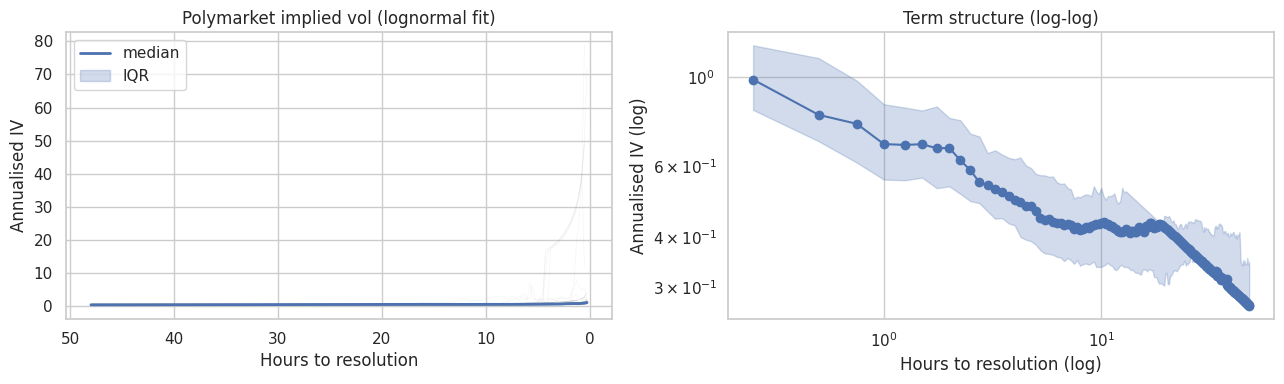

IV at  24h: 38.2%  (n=81)
IV at  12h: 41.4%  (n=81)
IV at   4h: 49.5%  (n=81)
IV at   1h: 68.0%  (n=81)


In [8]:
from scipy.optimize import minimize as _minimize

def fit_lognormal(lowers, uppers, probs):
    lowers = np.asarray(lowers, float); uppers = np.asarray(uppers, float)
    probs  = np.asarray(probs,  float)
    ln_lo  = np.log(np.maximum(lowers, 1.0)); ln_hi = np.log(uppers)
    mid    = (lowers + uppers) / 2.0; s = probs.sum()
    spot   = float((mid * probs).sum() / s) if s > 0 else float(mid.mean())
    def loss(theta):
        mu, log_sig = theta
        sig = np.exp(log_sig)
        pred = norm.cdf((ln_hi - mu) / sig) - norm.cdf((ln_lo - mu) / sig)
        return float(np.sum((pred - probs) ** 2))
    res = _minimize(loss, x0=[np.log(spot), np.log(0.02)], method='Nelder-Mead',
                    options={'xatol': 1e-5, 'fatol': 1e-8, 'maxiter': 400})
    mu, log_sig = res.x
    return mu, float(np.exp(log_sig)), res.fun

# Aggregate to (target_date, ttr_bin, band) and fit
snap_fit = (yes_15m.groupby(['target_date', 'ttr_bin', 'lower_price', 'upper_price'],
                             as_index=False)['price'].mean())

iv_recs = []
for (day, ttr_h), g in snap_fit.groupby(['target_date', 'ttr_bin']):
    if ttr_h <= 0 or ttr_h > 48 or len(g) < 4 or g['price'].sum() < 0.5:
        continue
    mu, sigma, err = fit_lognormal(g['lower_price'].values, g['upper_price'].values,
                                   g['price'].values)
    iv_recs.append({'target_date': day, 'ttr_h': ttr_h,
                    'mu': mu, 'spot_implied': np.exp(mu),
                    'sigma_h': sigma, 'fit_err': err})

iv_df = pd.DataFrame(iv_recs)
iv_df['tau_years'] = iv_df['ttr_h'] / 24.0 / 365.0
iv_df['iv_annual'] = iv_df['sigma_h'] / np.sqrt(iv_df['tau_years'])

iv_q = (iv_df.groupby('ttr_h')['iv_annual']
             .agg(median='median', q25=lambda s: s.quantile(0.25),
                  q75=lambda s: s.quantile(0.75), n='count')
             .reset_index())
iv_q = iv_q[iv_q['n'] >= 10]

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
ax = axes[0]
for d, g in iv_df.groupby('target_date'):
    ax.plot(g['ttr_h'], g['iv_annual'], color='grey', alpha=0.08, lw=0.5)
ax.plot(iv_q['ttr_h'], iv_q['median'], color='C0', lw=2, label='median')
ax.fill_between(iv_q['ttr_h'], iv_q['q25'], iv_q['q75'], color='C0', alpha=0.25, label='IQR')
ax.invert_xaxis(); ax.set_xlabel('Hours to resolution'); ax.set_ylabel('Annualised IV')
ax.set_title('Polymarket implied vol (lognormal fit)'); ax.legend()

ax = axes[1]
ax.plot(iv_q['ttr_h'], iv_q['median'], 'o-', color='C0')
ax.fill_between(iv_q['ttr_h'], iv_q['q25'], iv_q['q75'], color='C0', alpha=0.25)
ax.set_xscale('log'); ax.set_yscale('log')
ax.set_xlabel('Hours to resolution (log)'); ax.set_ylabel('Annualised IV (log)')
ax.set_title('Term structure (log-log)')
plt.tight_layout(); plt.show()

for ref_h in [24, 12, 4, 1]:
    row = iv_q.loc[(iv_q['ttr_h'] - ref_h).abs().idxmin()]
    print(f'IV at {ref_h:3d}h: {row["median"]*100:.1f}%  (n={int(row["n"])})')


### 4c. Implied volatility smile

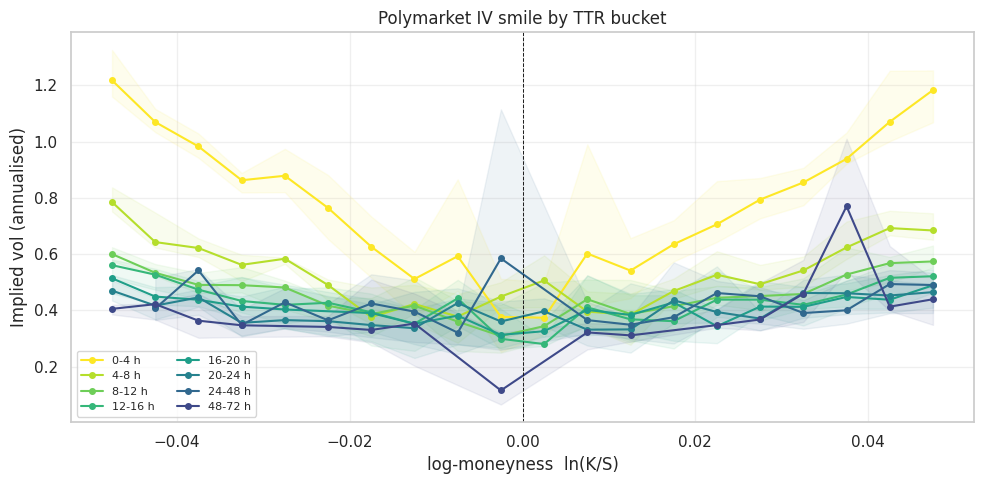

In [9]:
def implied_sigma_digital(P_above, S, K, tau):
    if not (0.0 < P_above < 1.0) or S <= 0 or K <= 0 or tau <= 0:
        return np.nan
    def f(sig):
        d2 = (np.log(S / K) - 0.5 * sig * sig * tau) / (sig * np.sqrt(tau))
        return norm.cdf(d2) - P_above
    try:
        return brentq(f, 1e-4, 5.0, maxiter=200)
    except Exception:
        return np.nan

smile_rows = []
for lo, hi, label in lookbacks_extended:
    snap_l = snapshot_in_window(lo, hi)
    if snap_l.empty:
        continue
    iv_lk = iv_df[(iv_df['ttr_h'] >= lo) & (iv_df['ttr_h'] < hi)]
    if not iv_lk.empty:
        iv_lk = iv_lk.groupby('target_date', as_index=False).agg(
            S=('spot_implied', 'median'), tau=('tau_years', 'median'))
    else:
        iv_lk = (snap_l.groupby('target_date', as_index=False)
                       .apply(lambda g: pd.Series({
                           'S': float((g['price'] * (g['lower_price']+g['upper_price'])/2).sum()
                                      / max(g['price'].sum(), 1e-9)),
                           'tau': ((lo+hi)/2) / 24 / 365}))
                       .reset_index(drop=True))
    snap_l = snap_l.merge(iv_lk, on='target_date', how='inner')
    for tgt, grp in snap_l.groupby('target_date'):
        gb = (grp.groupby('lower_price', as_index=False)
                 .agg(upper_price=('upper_price','first'),
                      p=('price','mean'), S=('S','first'), tau=('tau','first'))
                 .sort_values('lower_price').reset_index(drop=True))
        if gb['p'].sum() <= 0:
            continue
        gb['p'] = gb['p'] / gb['p'].sum()
        cum_right = gb['p'][::-1].cumsum()[::-1].values
        S_val = float(gb['S'].iloc[0]); tau_val = float(gb['tau'].iloc[0])
        for i in range(len(gb) - 1):
            K = float(gb['upper_price'].iloc[i]); P_above = float(cum_right[i + 1])
            sig = implied_sigma_digital(P_above, S_val, K, tau_val)
            if np.isfinite(sig):
                smile_rows.append({'ttr_label': label,
                                   'ttr_mid': (lo+hi)/2.,
                                   'log_moneyness': np.log(K/S_val),
                                   'sigma_bs': sig})

smile_df = pd.DataFrame(smile_rows)
smile_df['m_bin'] = pd.cut(smile_df['log_moneyness'], np.linspace(-0.05, 0.05, 21))
agg_smile = (smile_df.groupby(['ttr_label','ttr_mid','m_bin'], observed=True)['sigma_bs']
                     .agg(median='median',
                          q25=lambda s: s.quantile(0.25),
                          q75=lambda s: s.quantile(0.75),
                          n='count').reset_index())
agg_smile['m_mid'] = agg_smile['m_bin'].apply(lambda x: x.mid).astype(float)

labels_sorted = sorted(smile_df['ttr_label'].unique(),
                       key=lambda s: smile_df.loc[smile_df['ttr_label']==s,'ttr_mid'].iloc[0])
cmap_s = plt.get_cmap('viridis_r')
norm_s  = plt.Normalize(vmin=0, vmax=len(labels_sorted)-1)

fig, ax = plt.subplots(figsize=(10, 5))
for i, lbl in enumerate(labels_sorted):
    sub = agg_smile[(agg_smile['ttr_label']==lbl) & (agg_smile['n']>=5)].sort_values('m_mid')
    if sub.empty:
        continue
    c = cmap_s(norm_s(i))
    ax.plot(sub['m_mid'], sub['median'], '-o', color=c, label=f'{lbl}', lw=1.5, ms=4)
    ax.fill_between(sub['m_mid'], sub['q25'], sub['q75'], color=c, alpha=0.08)
ax.axvline(0, color='k', lw=0.7, ls='--')
ax.set_xlabel('log-moneyness  ln(K/S)'); ax.set_ylabel('Implied vol (annualised)')
ax.set_title('Polymarket IV smile by TTR bucket')
ax.legend(ncol=2, fontsize=8); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()


### 4d. Calibration reliability diagrams

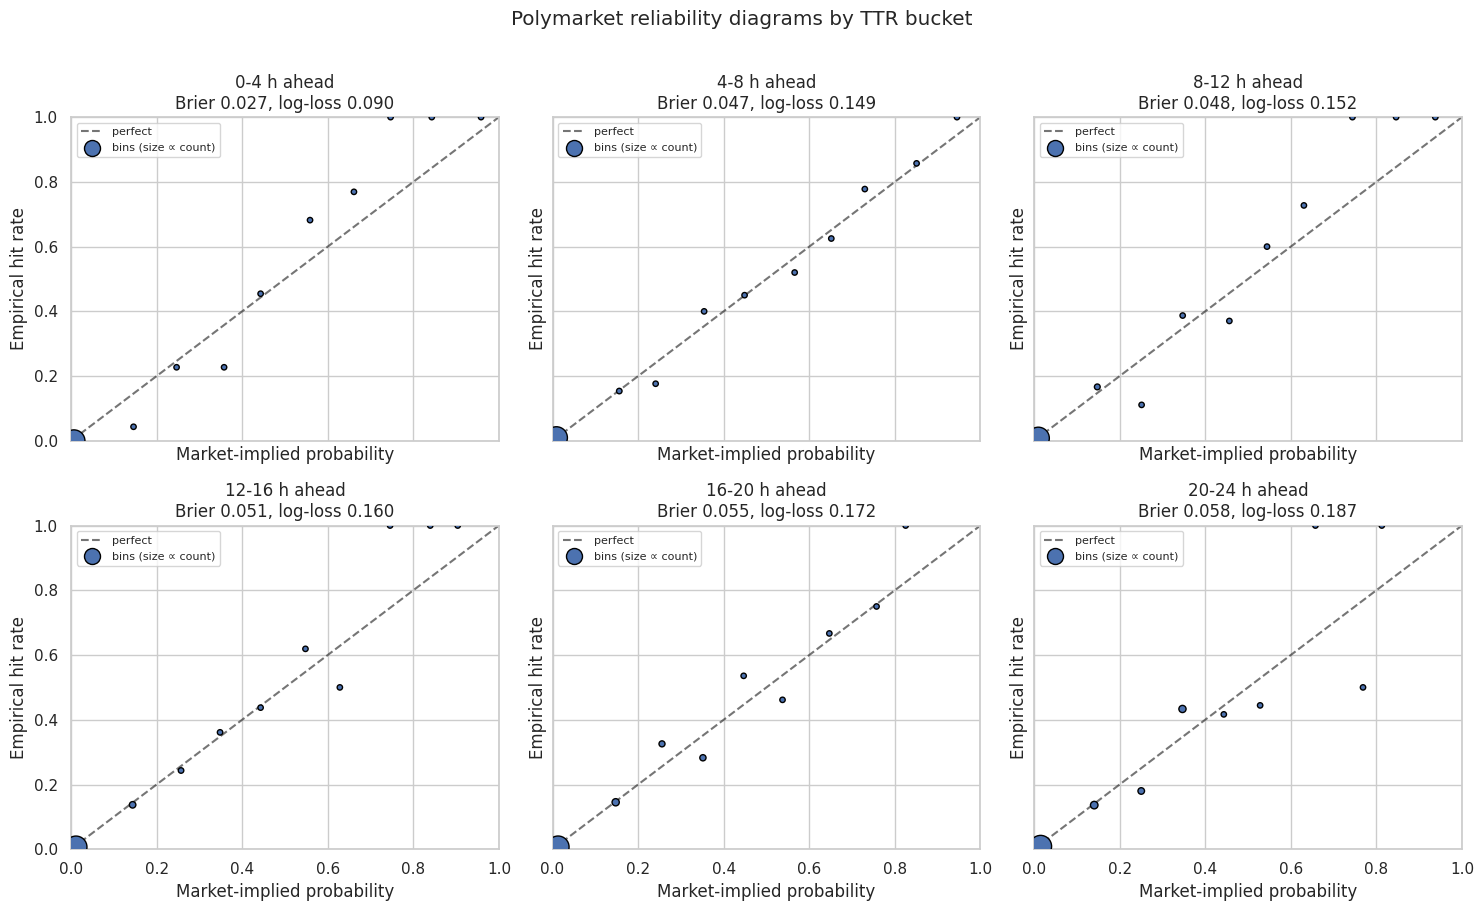

lookback  ttr_lo  ttr_hi  n_obs    brier  log_loss  base_rate
   0-4 h       0       4    777 0.027005  0.089773   0.091377
   4-8 h       4       8    777 0.046603  0.148934   0.091377
  8-12 h       8      12    777 0.047855  0.152485   0.091377
 12-16 h      12      16    777 0.050791  0.160334   0.091377
 16-20 h      16      20    777 0.054807  0.172316   0.091377
 20-24 h      20      24    777 0.058032  0.186709   0.091377


In [10]:
def calibration_table(snap_df, n_bins=10):
    df = snap_df.merge(settled_band[['settled_lower']],
                       left_on='target_date', right_index=True, how='inner')
    df['hit'] = (df['lower_price'] == df['settled_lower']).astype(int)
    df = df[['target_date','lower_price','price','hit']].dropna()
    edges = np.linspace(0, 1, n_bins + 1)
    df['bin'] = pd.cut(df['price'], edges, include_lowest=True)
    rel = (df.groupby('bin')
             .agg(mean_pred=('price','mean'), emp_freq=('hit','mean'), n=('hit','size'))
             .reset_index(drop=True))
    eps = 1e-6
    p = df['price'].clip(eps, 1-eps).values; y = df['hit'].values
    brier   = float(np.mean((p - y)**2))
    logloss = float(-np.mean(y*np.log(p) + (1-y)*np.log(1-p)))
    return df, rel, brier, logloss

fig, axes = plt.subplots(2, 3, figsize=(15, 9), sharex=True, sharey=True)
calib_metrics = []
for (lo, hi, label), ax in zip(lookbacks_fine, axes.ravel()):
    snap_df = snapshot_in_window(lo, hi)
    df, rel, brier, logloss = calibration_table(snap_df)
    calib_metrics.append({'lookback': label, 'ttr_lo': lo, 'ttr_hi': hi,
                          'n_obs': len(df), 'brier': brier, 'log_loss': logloss,
                          'base_rate': df['hit'].mean()})
    ax.plot([0,1],[0,1],'k--',alpha=0.6,label='perfect')
    sizes = (rel['n'] / max(rel['n'].max(),1) * 250).clip(lower=15)
    ax.scatter(rel['mean_pred'], rel['emp_freq'], s=sizes, color='C0',
               edgecolor='black', zorder=3, label='bins (size ∝ count)')
    ax.set_title(f'{label} ahead\nBrier {brier:.3f}, log-loss {logloss:.3f}')
    ax.set_xlabel('Market-implied probability'); ax.set_ylabel('Empirical hit rate')
    ax.set_xlim(0,1); ax.set_ylim(0,1); ax.legend(loc='upper left', fontsize=8)
plt.suptitle('Polymarket reliability diagrams by TTR bucket', y=1.01)
plt.tight_layout(); plt.show()

calib_df = pd.DataFrame(calib_metrics)
print(calib_df.to_string(index=False))


### 4e. Randomised probability integral transform (PIT)

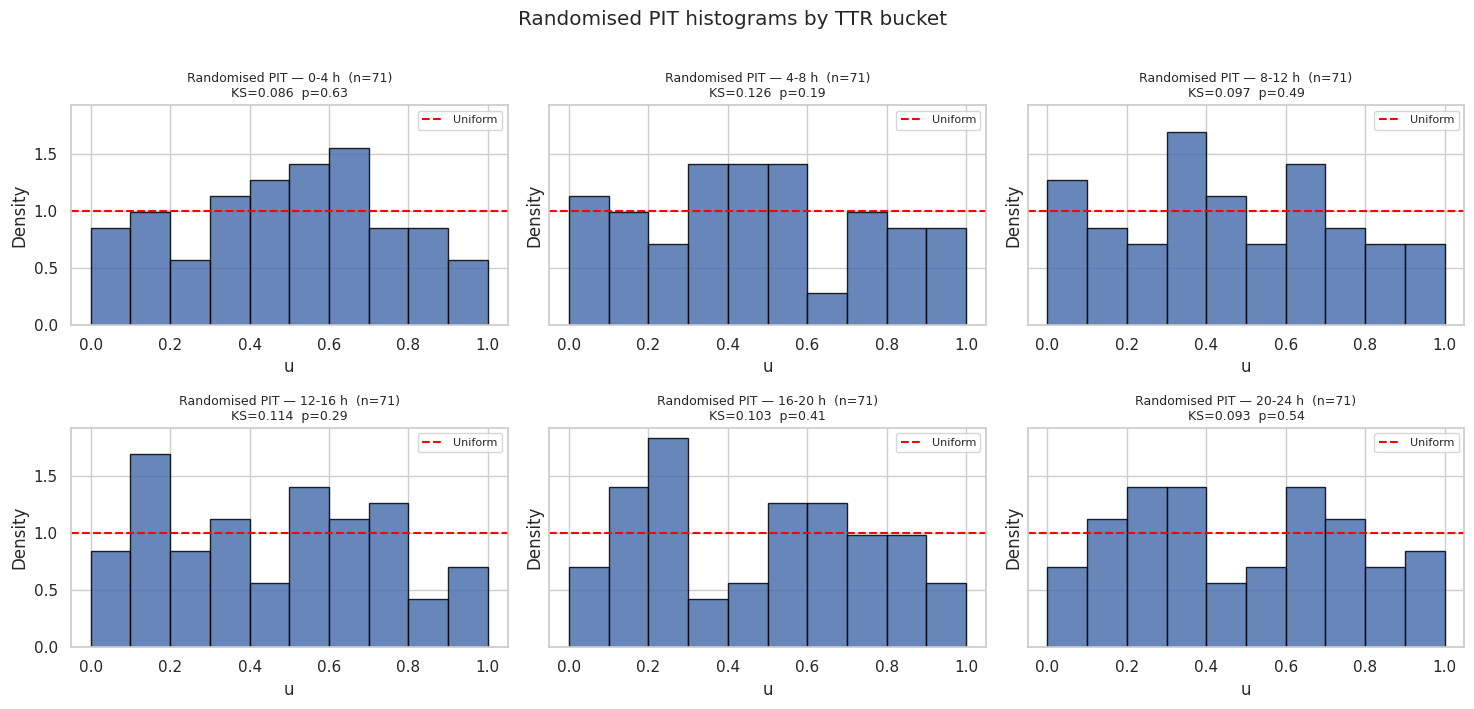

In [11]:
def randomized_pit(lo_h, hi_h, seed=42):
    rng = np.random.default_rng(seed)
    snap_df = snapshot_in_window(lo_h, hi_h)
    df = snap_df.merge(settled_band[['settled_lower']],
                       left_on='target_date', right_index=True, how='inner')
    out = []
    for day, g in df.groupby('target_date'):
        g = g.sort_values('lower_price')
        p = g['price'].values.astype(float); s = p.sum()
        if s <= 0:
            continue
        p = p / s
        lo_arr = g['lower_price'].values
        settled_lo = float(g['settled_lower'].iloc[0])
        idx = np.where(lo_arr == settled_lo)[0]
        if len(idx) == 0:
            continue
        k = int(idx[0])
        out.append(float(p[:k].sum()) + rng.uniform() * float(p[k]))
    return np.array(out)

fig, axes = plt.subplots(2, 3, figsize=(15, 7), sharey=True)
for (lo, hi, label), ax in zip(lookbacks_fine, axes.ravel()):
    u = randomized_pit(lo, hi)
    u = u[np.isfinite(u)]
    ax.hist(u, bins=10, range=(0,1), density=True,
            color='C0', edgecolor='black', alpha=0.85)
    ax.axhline(1.0, color='red', ls='--', label='Uniform')
    ks = kstest(u, 'uniform') if len(u) > 1 else None
    title = f'Randomised PIT — {label}  (n={len(u)})'
    if ks is not None:
        title += f'\nKS={ks.statistic:.3f}  p={ks.pvalue:.2g}'
    ax.set_title(title, fontsize=9)
    ax.set_xlabel('u'); ax.set_ylabel('Density'); ax.legend(fontsize=8)
plt.suptitle('Randomised PIT histograms by TTR bucket', y=1.01)
plt.tight_layout(); plt.show()


## 5. Benchmark Models

For each benchmark model we:
1. Fit on all available Binance daily data **strictly before** the resolution day.
2. Produce an **h-hour-ahead total log-return std** $\sigma_h$ for each TTR bucket.
3. Compute **lognormal band probabilities** $P([L_k, U_k]) = \Phi\!\left(\frac{\ln U_k - \ln S_t}{\sigma_h}\right) - \Phi\!\left(\frac{\ln L_k - \ln S_t}{\sigma_h}\right)$ using the Binance spot price $S_t$ at the snapshot time.

| Model | $\sigma_h$ |
|-------|------------|
| **RW-30d** | $\hat{\sigma}_{30\text{d}} \sqrt{h/24}$ |
| **RW-90d** | $\hat{\sigma}_{90\text{d}} \sqrt{h/24}$ |
| **GARCH(1,1)** | $\sqrt{\sum_{i=1}^{\lceil h/24 \rceil} \hat{V}_{t+i}^{\text{GARCH}}} \cdot \sqrt{h/(24 \cdot \lceil h/24 \rceil)}$ |
| **HAR-RV** | $\sqrt{\widehat{\text{RV}}_{t+1}^{\text{HAR}} \cdot h/24}$ |
| **Deribit ATM** | $\hat{\sigma}_{\text{Deribit}} \sqrt{h/24/365}$ (annualised → total) |


In [12]:
# ── Lognormal band probabilities ──────────────────────────────────────────────
def lognormal_band_probs(S, sigma_total, bands_df):
    '''Compute P(L < S_T < U) assuming S_T ~ LogNormal(ln S, sigma_total^2).'''
    if not np.isfinite(sigma_total) or sigma_total <= 0 or not np.isfinite(S) or S <= 0:
        return np.full(len(bands_df), np.nan)
    lowers = bands_df['lower_price'].values.astype(float)
    uppers = bands_df['upper_price'].values.astype(float)
    ln_S   = np.log(S)
    probs  = np.zeros(len(bands_df))
    for i, (lo, up) in enumerate(zip(lowers, uppers)):
        if lo <= 0:                         # lower tail (<min band)
            probs[i] = norm.cdf((np.log(up) - ln_S) / sigma_total)
        elif up >= UPPER_SENTINEL:          # upper tail (>max band)
            probs[i] = 1 - norm.cdf((np.log(lo) - ln_S) / sigma_total)
        else:
            probs[i] = (norm.cdf((np.log(up) - ln_S) / sigma_total) -
                        norm.cdf((np.log(lo) - ln_S) / sigma_total))
    return probs

# ── Scoring functions ─────────────────────────────────────────────────────────
def log_score(probs, hit_mask):
    '''Log-score: log-probability assigned to the realised band.'''
    p = float(probs[hit_mask].sum())
    return float(np.log(max(p, 1e-10)))

def brier_score_band(probs, hit_mask):
    '''Mean Brier score over all bands (proper scoring rule, lower = better).'''
    y = np.zeros(len(probs)); y[hit_mask] = 1.0
    return float(np.mean((np.array(probs) - y) ** 2))

def crps_pmf(probs, band_mids, y_actual):
    '''CRPS for a discrete distribution.
    Uses step-function CDF: CRPS = sum_k (F_k - H_k)^2 * (m_{k+1} - m_k).
    '''
    probs = np.array(probs, float); mids = np.array(band_mids, float)
    probs = probs / max(probs.sum(), 1e-10)
    idx = np.argsort(mids); probs = probs[idx]; mids = mids[idx]
    F = np.cumsum(probs); crps = 0.0
    for k in range(len(mids) - 1):
        crps += (F[k] - float(y_actual <= mids[k])) ** 2 * (mids[k+1] - mids[k])
    return float(crps)

# ── Diebold–Mariano test ──────────────────────────────────────────────────────
def diebold_mariano(loss1, loss2, h=1):
    '''
    DM test for equal predictive accuracy.
    H0: E[d_t] = 0,  d_t = L1_t - L2_t.
    Uses Newey-West HAC variance (bandwidth = h).
    Returns (DM-stat, p-value, mean differential).
    Positive DM → model 1 is less accurate (higher loss) than model 2.
    '''
    d = np.array(loss1, float) - np.array(loss2, float)
    n = len(d); mean_d = d.mean()
    if n < 4:
        return np.nan, np.nan, float(mean_d)
    lags = max(h, 1)
    gamma0 = float(np.var(d, ddof=1))
    gamma_sum = gamma0
    for j in range(1, lags + 1):
        w = 1 - j / (lags + 1)
        if j < n:
            gamma_j = float(np.cov(d[j:], d[:-j])[0, 1])
        else:
            gamma_j = 0.0
        gamma_sum += 2 * w * gamma_j
    var_hac = max(gamma_sum / n, 1e-14)
    dm_stat = mean_d / np.sqrt(var_hac)
    p_val   = 2 * (1 - norm.cdf(abs(dm_stat)))
    return float(dm_stat), float(p_val), float(mean_d)


In [13]:
# ── GARCH(1,1) ────────────────────────────────────────────────────────────────
def fit_garch11(daily_returns):
    r = daily_returns.dropna().values * 100  # arch expects %
    if len(r) < 50:
        return None
    try:
        model  = arch_model(r, vol='Garch', p=1, q=1, dist='Normal', mean='Constant')
        result = model.fit(disp='off', show_warning=False)
        return result
    except Exception:
        return None

def garch_sigma_h(garch_result, n_days_ahead):
    '''Total log-return std over n_days_ahead from a fitted GARCH(1,1) model.'''
    if garch_result is None:
        return np.nan
    try:
        fc  = garch_result.forecast(horizon=n_days_ahead, reindex=False)
        var = fc.variance.values[-1]           # shape (n_days_ahead,) in (%)^2
        return float(np.sqrt(max(var.sum(), 0) / 100**2))
    except Exception:
        return np.nan

# ── HAR-RV ────────────────────────────────────────────────────────────────────
def fit_har_rv(rv_series):
    rv = np.array(rv_series, float)
    rv = rv[~np.isnan(rv)]
    if len(rv) < 30:
        return None
    n = len(rv)
    # y = RV_{t+1}
    y = rv[22:]
    X_d = rv[21:n-1]
    X_w = np.array([rv[max(0, i-4):i+1].mean() for i in range(21, n-1)])
    X_m = np.array([rv[max(0, i-21):i+1].mean() for i in range(21, n-1)])
    X   = np.column_stack([np.ones(len(y)), X_d, X_w, X_m])
    try:
        beta = np.linalg.lstsq(X, y, rcond=None)[0]
        return beta
    except Exception:
        return None

def har_forecast_rv(beta, recent_rv):
    '''One-step-ahead HAR-RV: returns daily realised variance forecast.'''
    if beta is None or len(recent_rv) < 22:
        return np.nan
    rv = np.array(recent_rv, float)
    rv_d = rv[-1]
    rv_w = rv[-5:].mean()
    rv_m = rv[-22:].mean()
    return float(max(beta[0] + beta[1]*rv_d + beta[2]*rv_w + beta[3]*rv_m, 1e-10))


### 5a. Fit models per resolution day

In [14]:
resolution_dates = sorted(yes['target_date'].unique())
daily_params = {}   # date → {model params / vol estimates}

print(f'Fitting models for {len(resolution_dates)} resolution days …')
for date in tqdm(resolution_dates, desc='Fitting'):
    # Historical data: everything strictly before resolution date
    cutoff_date = date.normalize()
    hist = daily[daily['date'] < cutoff_date].copy()
    if len(hist) < 30:
        daily_params[date] = {}
        continue

    # Rolling vol estimates (daily log-return std over windows)
    rv30 = float(hist['log_ret_d'].iloc[-30:].std(ddof=1)) if len(hist) >= 30 else np.nan
    rv90 = float(hist['log_ret_d'].iloc[-90:].std(ddof=1)) if len(hist) >= 90 else np.nan
    rv_long = float(hist['log_ret_d'].std(ddof=1))

    # GARCH(1,1) on daily returns
    garch_res = fit_garch11(hist['log_ret_d'])

    # HAR-RV on daily realised variance
    har_beta = fit_har_rv(hist['rv_daily'])
    last_rv  = hist['rv_daily'].values[-30:]  # recent RV for forecast

    # Deribit ATM IV (already computed)
    deribit_iv = deribit_atm_iv.get(date, np.nan)

    daily_params[date] = dict(
        rv30=rv30, rv90=rv90, rv_long=rv_long,
        garch=garch_res, har_beta=har_beta, last_rv=last_rv,
        deribit_iv=deribit_iv,
    )

print('Done.')


Fitting models for 81 resolution days …


Fitting:   0%|          | 0/81 [00:00<?, ?it/s]

Done.


### 5b. Compute band probabilities for all models at each TTR bucket

In [15]:
MODEL_NAMES = ['polymarket', 'rv30', 'rv90', 'garch', 'har', 'deribit']

all_evals = []

for lo_h, hi_h, label in tqdm(lookbacks_fine, desc='TTR buckets'):
    ttr_mid = (lo_h + hi_h) / 2.0
    snap_df = snapshot_in_window(lo_h, hi_h)
    tau_frac = ttr_mid / 24.0  # fraction of a trading day

    for date, grp in snap_df.groupby('target_date'):
        bands = grp[['lower_price','upper_price','price']].sort_values('lower_price').copy()
        bands['band_mid'] = (bands['lower_price'] + bands['upper_price']) / 2.0
        bands.loc[bands['lower_price']==0, 'band_mid'] = (
            bands.loc[bands['lower_price']==0, 'upper_price'] / 2)
        bands.loc[bands['upper_price']>=UPPER_SENTINEL, 'band_mid'] = (
            bands.loc[bands['upper_price']>=UPPER_SENTINEL, 'lower_price'] * 1.5)
        bands = bands.reset_index(drop=True)

        # Actual Binance spot at snapshot time
        S = get_spot_at_ttr(date, ttr_mid)
        if not np.isfinite(S) or S <= 0:
            continue

        # Outcome: which band was the winner?
        if date not in settled_all.index:
            continue
        s_row = settled_all.loc[date]
        settled_lo = float(s_row['settled_lower'])
        settled_up = float(s_row['settled_upper'])

        def _hit(lo, up):
            if lo <= 0 and settled_lo <= 0:
                return 1
            if up >= UPPER_SENTINEL and settled_up >= UPPER_SENTINEL:
                return 1
            return int(lo == settled_lo)

        hit_mask = np.array([_hit(r['lower_price'], r['upper_price'])
                             for _, r in bands.iterrows()], bool)
        if not hit_mask.any():
            continue

        params = daily_params.get(date, {})
        n_bands = len(bands)

        # ─── Model probabilities ────────────────────────────────────────────
        # Polymarket
        p_pm_raw = bands['price'].values.astype(float)
        p_pm = p_pm_raw / max(p_pm_raw.sum(), 1e-9)

        # RW-30d
        rv30 = params.get('rv30', np.nan)
        sig30 = rv30 * np.sqrt(tau_frac) if np.isfinite(rv30) else np.nan
        p_rv30 = lognormal_band_probs(S, sig30, bands)

        # RW-90d
        rv90 = params.get('rv90', np.nan)
        sig90 = rv90 * np.sqrt(tau_frac) if np.isfinite(rv90) else np.nan
        p_rv90 = lognormal_band_probs(S, sig90, bands)

        # GARCH
        n_days = max(1, int(np.ceil(tau_frac)))
        sig_g  = garch_sigma_h(params.get('garch'), n_days)
        # Scale to exact TTR fraction
        sig_g  = sig_g * np.sqrt(tau_frac / n_days) if np.isfinite(sig_g) else np.nan
        p_garch = lognormal_band_probs(S, sig_g, bands)

        # HAR-RV
        har_beta   = params.get('har_beta')
        last_rv_arr = params.get('last_rv', [])
        rv_hat = har_forecast_rv(har_beta, last_rv_arr)
        sig_har = np.sqrt(rv_hat * tau_frac) if np.isfinite(rv_hat) else np.nan
        p_har = lognormal_band_probs(S, sig_har, bands)

        # Deribit ATM IV (annualised → total)
        d_iv = params.get('deribit_iv', np.nan)
        tau_years = tau_frac / 365.0
        sig_deribit = d_iv * np.sqrt(tau_years) if np.isfinite(d_iv) and d_iv > 0 else np.nan
        p_deribit = lognormal_band_probs(S, sig_deribit, bands)

        all_probs = {
            'polymarket': p_pm,
            'rv30':       p_rv30,
            'rv90':       p_rv90,
            'garch':      p_garch,
            'har':        p_har,
            'deribit':    p_deribit,
        }

        # Band midpoints for CRPS (use actual BTC settlement price if available)
        y_actual = get_spot_at_ttr(date, 0)  # price at resolution
        band_mids = bands['band_mid'].values.astype(float)

        row = dict(
            target_date=date, ttr_label=label, ttr_lo=lo_h, ttr_hi=hi_h,
            S_t=S, y_actual=y_actual,
            is_lower_tail=(date in edge_lower_days),
            is_upper_tail=(date in edge_upper_days),
        )

        for mname, probs in all_probs.items():
            valid = np.all(np.isfinite(probs))
            if valid:
                row[f'logscore_{mname}']  = log_score(probs, hit_mask)
                row[f'brier_{mname}']     = brier_score_band(probs, hit_mask)
                row[f'crps_{mname}']      = crps_pmf(probs, band_mids, y_actual)
            else:
                row[f'logscore_{mname}']  = np.nan
                row[f'brier_{mname}']     = np.nan
                row[f'crps_{mname}']      = np.nan

        all_evals.append(row)

eval_df = pd.DataFrame(all_evals)
print(f'Evaluation rows: {len(eval_df):,}  '
      f'({eval_df["target_date"].nunique()} days × {eval_df["ttr_label"].nunique()} TTR buckets)')
print(eval_df[['ttr_label','logscore_polymarket','logscore_rv30','logscore_garch',
               'crps_polymarket','crps_rv30','crps_garch']].describe().round(4))


TTR buckets:   0%|          | 0/6 [00:00<?, ?it/s]

Evaluation rows: 480  (80 days × 6 TTR buckets)
       logscore_polymarket  logscore_rv30  logscore_garch  crps_polymarket  \
count             480.0000       480.0000        480.0000         480.0000   
mean               -0.9329        -1.8173         -1.7236        4030.7362   
std                 0.7582         2.4553          2.3651        9584.5219   
min                -4.9320       -23.0259        -23.0259           0.5004   
25%                -1.1690        -2.0855         -1.9577         380.0523   
50%                -0.7930        -1.0146         -1.0136         791.3661   
75%                -0.4377        -0.6214         -0.6618        1564.5822   
max                -0.0050        -0.0000         -0.0000       48513.5643   

        crps_rv30  crps_garch  
count    480.0000    480.0000  
mean    3694.8503   3631.5851  
std     8982.2896   8768.0443  
min        0.3560      8.6425  
25%      423.1516    421.0642  
50%      922.7049    908.8954  
75%     1935.8941   1875.

## 6. Calibration Metrics Comparison

For each model × TTR bucket we report:
* **Log-score** (higher = better; best possible = log(1) = 0)
* **CRPS** (lower = better)
* **Brier score** (lower = better)

Polymarket is the "live market" forecast; all other models are statistical
benchmarks using only the historical Binance price series and Deribit IV.


In [16]:
MODEL_LABELS = {
    'polymarket': 'Polymarket',
    'rv30':       'RW-30d',
    'rv90':       'RW-90d',
    'garch':      'GARCH(1,1)',
    'har':        'HAR-RV',
    'deribit':    'Deribit ATM',
}
METRIC_COLS = ['logscore', 'brier', 'crps']

summary_rows = []
for ttr_label, grp in eval_df.groupby('ttr_label'):
    for mname, mlabel in MODEL_LABELS.items():
        row = {'TTR': ttr_label, 'Model': mlabel}
        for m in METRIC_COLS:
            col = f'{m}_{mname}'
            vals = grp[col].dropna()
            row[m.upper()] = round(float(vals.mean()), 4) if len(vals) > 0 else np.nan
            row[f'n_{m}'] = len(vals)
        summary_rows.append(row)

summary = pd.DataFrame(summary_rows)

# Pivot: one column per model, rows = TTR bucket × metric
for metric in ['LOGSCORE', 'BRIER', 'CRPS']:
    pivot = summary.pivot_table(index='TTR', columns='Model', values=metric)
    # Reorder columns
    ordered_cols = [v for v in MODEL_LABELS.values() if v in pivot.columns]
    pivot = pivot[ordered_cols]
    print(f'\n─── {metric} ({"higher better" if metric=="LOGSCORE" else "lower better"}) ───')
    print(pivot.round(4).to_string())



─── LOGSCORE (higher better) ───
Model    Polymarket  RW-30d  RW-90d  GARCH(1,1)  HAR-RV  Deribit ATM
TTR                                                                 
0-4 h       -0.4790 -2.4673 -2.4207     -2.2843 -2.1209      -1.9112
12-16 h     -1.0060 -1.7343 -1.7369     -1.6265 -1.5941      -1.5663
16-20 h     -1.0961 -1.6235 -1.6392     -1.5486 -1.5316      -1.4852
20-24 h     -1.1887 -1.6470 -1.6713     -1.5742 -1.5639      -1.5211
4-8 h       -0.8895 -1.6733 -1.7310     -1.6407 -1.5948      -1.4870
8-12 h      -0.9384 -1.7582 -1.7653     -1.6676 -1.6048      -1.5781

─── BRIER (lower better) ───
Model    Polymarket  RW-30d  RW-90d  GARCH(1,1)  HAR-RV  Deribit ATM
TTR                                                                 
0-4 h        0.0243  0.0653  0.0645      0.0641  0.0626       0.0595
12-16 h      0.0490  0.0691  0.0675      0.0671  0.0667       0.0651
16-20 h      0.0529  0.0678  0.0668      0.0659  0.0658       0.0636
20-24 h      0.0549  0.0685  0.0686    

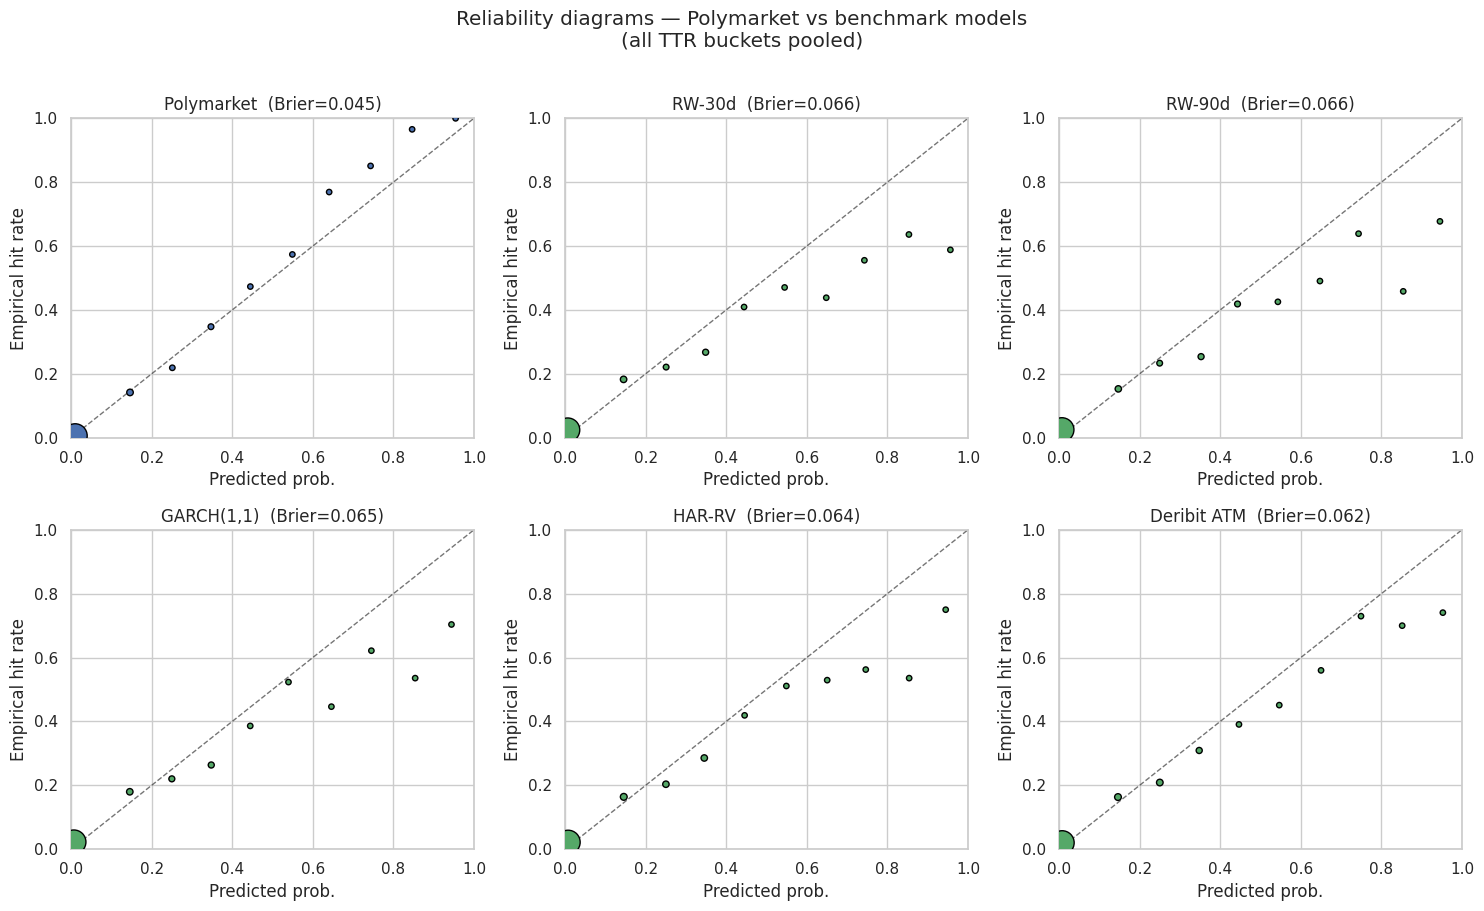

In [17]:
# ── Per-model reliability diagram, aggregated over all TTR buckets ────────────
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
n_bins = 10
edges  = np.linspace(0, 1, n_bins + 1)

for ax, (mname, mlabel) in zip(axes.ravel(), MODEL_LABELS.items()):
    rows_m = []
    for lo, hi, label in lookbacks_fine:
        snap_df = snapshot_in_window(lo, hi)
        ttr_mid = (lo + hi) / 2.0
        for date, grp in snap_df.groupby('target_date'):
            bands = grp[['lower_price','upper_price','price']].sort_values('lower_price').copy()
            bands = bands.reset_index(drop=True)
            if date not in settled_all.index:
                continue
            s_row = settled_all.loc[date]
            settled_lo = float(s_row['settled_lower'])
            settled_up = float(s_row['settled_upper'])
            S = get_spot_at_ttr(date, ttr_mid)
            params = daily_params.get(date, {})
            tau_frac = ttr_mid / 24.0

            if mname == 'polymarket':
                p_raw = bands['price'].values.astype(float)
                probs = p_raw / max(p_raw.sum(), 1e-9)
            elif mname == 'rv30':
                rv = params.get('rv30', np.nan)
                probs = lognormal_band_probs(S, rv*np.sqrt(tau_frac) if np.isfinite(rv) else np.nan, bands)
            elif mname == 'rv90':
                rv = params.get('rv90', np.nan)
                probs = lognormal_band_probs(S, rv*np.sqrt(tau_frac) if np.isfinite(rv) else np.nan, bands)
            elif mname == 'garch':
                n_days = max(1, int(np.ceil(tau_frac)))
                sig_g  = garch_sigma_h(params.get('garch'), n_days)
                sig_g  = sig_g * np.sqrt(tau_frac/n_days) if np.isfinite(sig_g) else np.nan
                probs  = lognormal_band_probs(S, sig_g, bands)
            elif mname == 'har':
                rv_hat = har_forecast_rv(params.get('har_beta'), params.get('last_rv', []))
                sig    = np.sqrt(rv_hat * tau_frac) if np.isfinite(rv_hat) else np.nan
                probs  = lognormal_band_probs(S, sig, bands)
            elif mname == 'deribit':
                d_iv = params.get('deribit_iv', np.nan)
                sig  = d_iv * np.sqrt(tau_frac/365) if np.isfinite(d_iv) and d_iv>0 else np.nan
                probs = lognormal_band_probs(S, sig, bands)
            else:
                continue

            if not np.all(np.isfinite(probs)):
                continue
            for i, brow in bands.iterrows():
                lo_b = brow['lower_price']; up_b = brow['upper_price']
                if lo_b <= 0:
                    hit = 1 if settled_lo <= 0 else 0
                elif up_b >= UPPER_SENTINEL:
                    hit = 1 if settled_up >= UPPER_SENTINEL else 0
                else:
                    hit = int(lo_b == settled_lo)
                rows_m.append({'p': float(probs[i]), 'hit': hit})

    if not rows_m:
        ax.set_title(f'{mlabel} — no data')
        continue
    df_m = pd.DataFrame(rows_m)
    df_m['bin'] = pd.cut(df_m['p'], edges, include_lowest=True)
    rel = (df_m.groupby('bin')
               .agg(mean_p=('p','mean'), emp=('hit','mean'), n=('hit','size'))
               .reset_index(drop=True))
    brier = float(np.mean((df_m['p'].values - df_m['hit'].values)**2))
    ax.plot([0,1],[0,1],'k--',alpha=0.6,lw=1)
    sizes = (rel['n'] / max(rel['n'].max(),1) * 300).clip(lower=15)
    ax.scatter(rel['mean_p'], rel['emp'], s=sizes, edgecolor='black', zorder=3,
               color='C0' if mname=='polymarket' else 'C2')
    ax.set_title(f'{mlabel}  (Brier={brier:.3f})')
    ax.set_xlabel('Predicted prob.'); ax.set_ylabel('Empirical hit rate')
    ax.set_xlim(0,1); ax.set_ylim(0,1)

plt.suptitle('Reliability diagrams — Polymarket vs benchmark models\n(all TTR buckets pooled)',
             y=1.01)
plt.tight_layout(); plt.show()


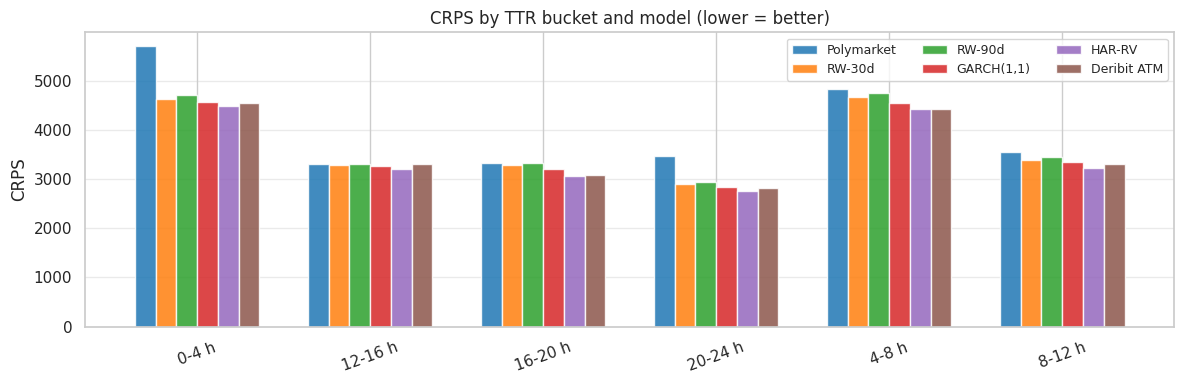

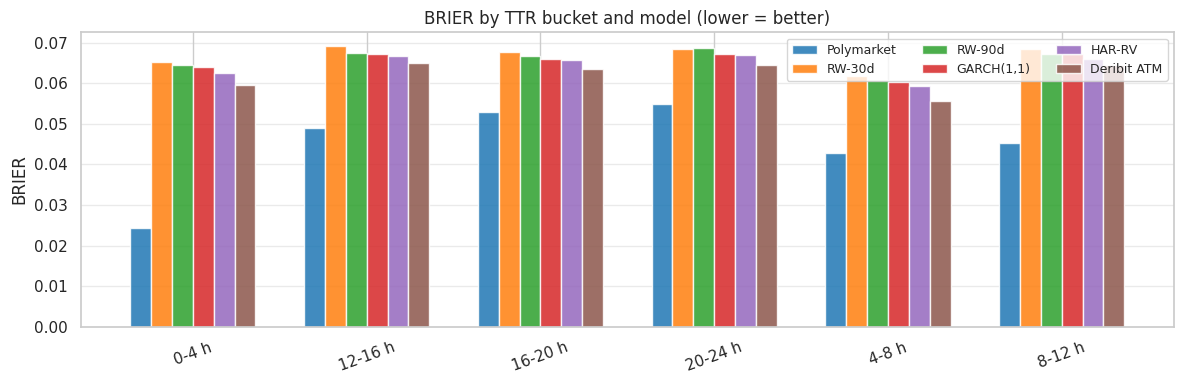

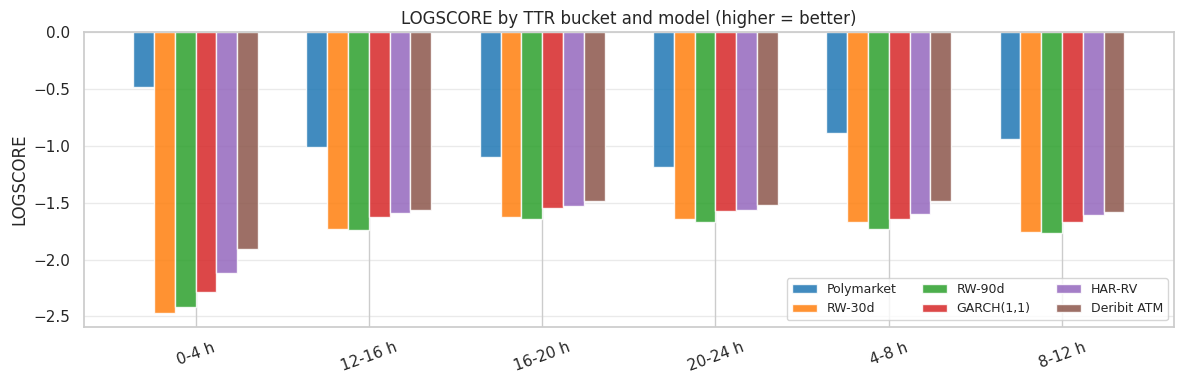

In [18]:
# ── Metric comparison bar charts ─────────────────────────────────────────────
for metric in ['CRPS', 'BRIER', 'LOGSCORE']:
    pivot = summary.pivot_table(index='TTR', columns='Model', values=metric)
    ordered_cols = [v for v in MODEL_LABELS.values() if v in pivot.columns]
    pivot = pivot[ordered_cols]

    fig, ax = plt.subplots(figsize=(12, 4))
    x = np.arange(len(pivot))
    w = 0.12
    cmap_b = plt.get_cmap('tab10')
    for j, col in enumerate(pivot.columns):
        offset = (j - len(pivot.columns)/2) * w + w/2
        ax.bar(x + offset, pivot[col], width=w, label=col, color=cmap_b(j), alpha=0.85)

    ax.set_xticks(x)
    ax.set_xticklabels(pivot.index, rotation=20)
    direction = '(higher = better)' if metric == 'LOGSCORE' else '(lower = better)'
    ax.set_title(f'{metric} by TTR bucket and model {direction}')
    ax.set_ylabel(metric)
    ax.legend(ncol=3, fontsize=9)
    ax.grid(axis='y', alpha=0.4)
    plt.tight_layout(); plt.show()


## 7. Diebold–Mariano Tests

The Diebold–Mariano (DM) test compares the predictive accuracy of two forecasts
by testing whether the mean loss differential $\bar{d} = \overline{L_1 - L_2}$
is zero.  We use Newey–West HAC standard errors to account for serial correlation.

Rows: each benchmark model vs. Polymarket.
Columns: each TTR bucket.
**Positive DM stat** → benchmark model is *less accurate* than Polymarket.
Significance levels: `*` p<0.10, `**` p<0.05, `***` p<0.01.


In [19]:
def stars(p):
    if p < 0.01:  return '***'
    if p < 0.05:  return '**'
    if p < 0.10:  return '*'
    return ''

for metric in ['crps', 'brier', 'logscore']:
    sign = -1 if metric == 'logscore' else 1   # for log-score: higher = better, invert
    print(f'\n══════ Diebold–Mariano: {metric.upper()} loss ══════')
    print('  (positive DM => benchmark WORSE than Polymarket)')

    header = f"{'Model':<15}" + ''.join(f'{lbl:>14}' for _, _, lbl in lookbacks_fine)
    print(header)
    print('-' * len(header))

    for mname, mlabel in MODEL_LABELS.items():
        if mname == 'polymarket':
            continue
        row_str = f'{mlabel:<15}'
        for lo, hi, lbl in lookbacks_fine:
            sub = eval_df[eval_df['ttr_label'] == lbl]
            pm_loss  = sub[f'{metric}_polymarket'].dropna()
            bm_loss  = sub[f'{metric}_{mname}'].dropna()
            # Align by target_date
            common = sub.dropna(subset=[f'{metric}_polymarket', f'{metric}_{mname}'])
            if len(common) < 5:
                row_str += f'{"n/a":>14}'
                continue
            l1 = sign * common[f'{metric}_{mname}'].values
            l2 = sign * common[f'{metric}_polymarket'].values
            dm, pv, md = diebold_mariano(l1, l2, h=1)
            cell = f'{dm:+.2f}{stars(pv)}' if np.isfinite(dm) else 'n/a'
            row_str += f'{cell:>14}'
        print(row_str)



══════ Diebold–Mariano: CRPS loss ══════
  (positive DM => benchmark WORSE than Polymarket)
Model                   0-4 h         4-8 h        8-12 h       12-16 h       16-20 h       20-24 h
---------------------------------------------------------------------------------------------------
RW-30d                  -1.02         -0.23         -0.18         -0.01         -0.06         -1.09
RW-90d                  -0.93         -0.13         -0.10         +0.00         -0.01         -1.01
GARCH(1,1)              -1.09         -0.40         -0.24         -0.05         -0.18         -1.20
HAR-RV                  -1.18         -0.61         -0.38         -0.11         -0.40         -1.34
Deribit ATM             -1.16         -0.67         -0.36         -0.07         -0.46         -1.29

══════ Diebold–Mariano: BRIER loss ══════
  (positive DM => benchmark WORSE than Polymarket)
Model                   0-4 h         4-8 h        8-12 h       12-16 h       16-20 h       20-24 h
-------------

## 8. Edge Cases: Tail Resolution Days

On **lower tail days** (BTC resolved below all finite bands) and
**upper tail days** (BTC resolved above all finite bands) the Polymarket crowd
was assigning positive probability to a large set of finite bands that all ended
up worthless.  These are the hardest cases for any model.

We compare:
1. **Calibration on tail vs non-tail days** (Brier, CRPS, log-score)
2. **Reliability diagrams split by tail/non-tail**
3. **Polymarket probability assigned to the winning tail band** as a function of TTR
4. **Comparative performance**: does Polymarket do better or worse than benchmarks
   on tail days?


In [20]:
# ── 8a. Metrics split: tail vs non-tail days ──────────────────────────────────
eval_df['tail'] = eval_df['is_lower_tail'] | eval_df['is_upper_tail']

split_rows = []
for tail_flag, tail_label in [(False, 'Non-tail'), (True, 'Tail')]:
    sub = eval_df[eval_df['tail'] == tail_flag]
    for mname, mlabel in MODEL_LABELS.items():
        row = {'Subset': tail_label, 'Model': mlabel, 'n_days': sub['target_date'].nunique()}
        for m in ['logscore', 'brier', 'crps']:
            col  = f'{m}_{mname}'
            vals = sub[col].dropna()
            row[m.upper()] = round(float(vals.mean()), 4) if len(vals) > 0 else np.nan
        split_rows.append(row)

split_df = pd.DataFrame(split_rows)

print('Tail vs non-tail — metrics pooled over all TTR buckets')
for metric in ['LOGSCORE', 'BRIER', 'CRPS']:
    pivot = split_df.pivot_table(index='Subset', columns='Model', values=metric)
    ordered = [v for v in MODEL_LABELS.values() if v in pivot.columns]
    print(f'\n{metric}:')
    print(pivot[ordered].round(4).to_string())


Tail vs non-tail — metrics pooled over all TTR buckets

LOGSCORE:
Model     Polymarket  RW-30d  RW-90d  GARCH(1,1)  HAR-RV  Deribit ATM
Subset                                                               
Non-tail     -0.9910 -1.9045 -1.8993     -1.8069 -1.7564      -1.6759
Tail         -0.4749 -1.1291 -1.2605     -1.0670 -0.9739      -0.9446

BRIER:
Model     Polymarket  RW-30d  RW-90d  GARCH(1,1)  HAR-RV  Deribit ATM
Subset                                                               
Non-tail      0.0476  0.0693  0.0679      0.0677  0.0673       0.0647
Tail          0.0233  0.0468  0.0497      0.0461  0.0434       0.0424

CRPS:
Model     Polymarket      RW-30d      RW-90d  GARCH(1,1)      HAR-RV  Deribit ATM
Subset                                                                           
Non-tail   1282.7205   1777.3684   1798.9813   1744.1873   1709.9705    1790.3896
Tail      25709.5268  18821.6518  19101.2309  18521.0561  17877.6526   17323.4865


In [21]:
# ── 8b. Polymarket probability on winning tail band vs TTR ──────────────────────
tail_days = sorted(edge_lower_days | edge_upper_days)

if tail_days:
    tail_pm_rows = []
    for lo_h, hi_h, label in lookbacks_fine:
        snap_df = snapshot_in_window(lo_h, hi_h)
        ttr_mid = (lo_h + hi_h) / 2.0
        for date in tail_days:
            if date not in snap_df['target_date'].values:
                continue
            grp = snap_df[snap_df['target_date'] == date]
            # Find the winning edge band
            s_row = settled_all.loc[date]
            settled_lo = float(s_row['settled_lower'])
            settled_up = float(s_row['settled_upper'])
            if settled_lo <= 0:
                winner_row = grp[grp['lower_price'] == 0]
            elif settled_up >= UPPER_SENTINEL:
                winner_row = grp[grp['upper_price'] >= UPPER_SENTINEL]
            else:
                continue
            if winner_row.empty:
                continue
            p_win = float(winner_row['price'].mean())
            p_sum = grp['price'].sum()
            tail_pm_rows.append({
                'target_date': date,
                'ttr_label': label,
                'ttr_lo': lo_h,
                'ttr_mid': ttr_mid,
                'p_winning_tail': p_win,
                'p_total': p_sum,
                'p_winning_norm': p_win / max(p_sum, 1e-9),
                'tail_type': 'lower' if settled_lo <= 0 else 'upper',
            })

    if tail_pm_rows:
        tail_pm_df = pd.DataFrame(tail_pm_rows)

        fig, axes = plt.subplots(1, 2, figsize=(13, 4))
        ax = axes[0]
        for date, g in tail_pm_df.groupby('target_date'):
            ax.plot(g['ttr_mid'], g['p_winning_norm'], 'o-', alpha=0.7, lw=1.2,
                    label=str(pd.Timestamp(date).date()))
        ax.set_xlabel('Hours to resolution (midpoint of TTR bucket)')
        ax.set_ylabel('Normalised P(winning tail band)')
        ax.set_title('Polymarket probability on winning tail band\n(tail resolution days only)')
        ax.invert_xaxis()
        ax.legend(fontsize=7, ncol=2)
        ax.axhline(0.5, color='k', ls='--', alpha=0.4, label='50%')

        ax = axes[1]
        mean_by_ttr = tail_pm_df.groupby('ttr_mid')['p_winning_norm'].agg(
            median='median', q25=lambda s: s.quantile(0.25), q75=lambda s: s.quantile(0.75))
        ax.plot(mean_by_ttr.index, mean_by_ttr['median'], 'o-', color='C3', lw=2,
                label='Median across tail days')
        ax.fill_between(mean_by_ttr.index, mean_by_ttr['q25'], mean_by_ttr['q75'],
                        color='C3', alpha=0.25)
        ax.set_xlabel('Hours to resolution')
        ax.set_ylabel('Normalised P(winning tail band)')
        ax.set_title('Median implied tail probability vs TTR\n(lower tail days)')
        ax.invert_xaxis()
        ax.legend()
        plt.tight_layout(); plt.show()
else:
    print('No tail resolution days found in data.')


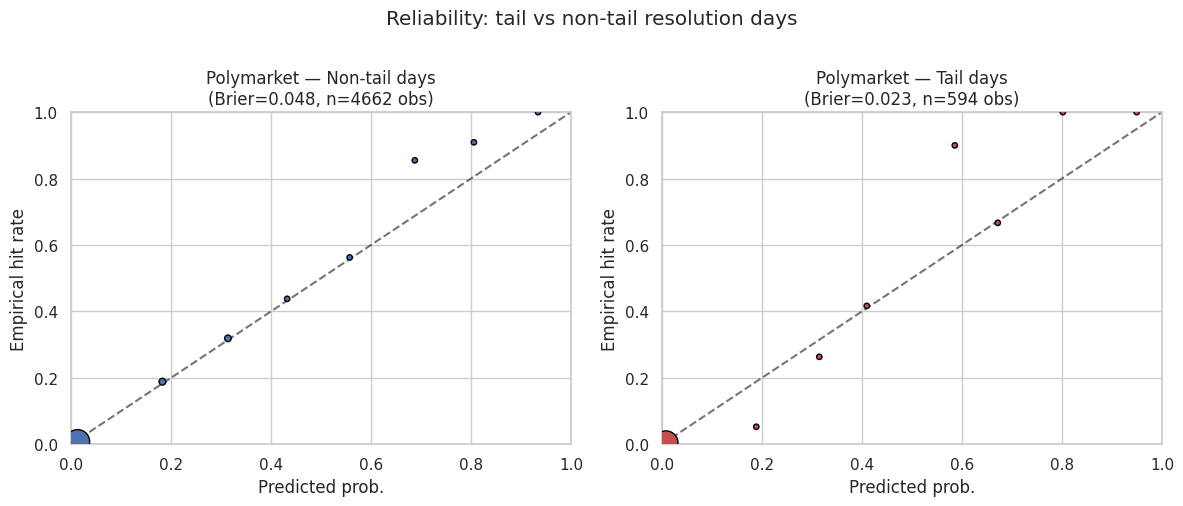

In [22]:
# ── 8c. Reliability: tail vs non-tail days ────────────────────────────────────
if tail_days:
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    n_bins = 8
    edges  = np.linspace(0, 1, n_bins + 1)

    for ax, (subset_flag, subset_label) in zip(axes, [(False,'Non-tail days'),(True,'Tail days')]):
        sub_eval = eval_df[eval_df['tail'] == subset_flag]
        rows_r   = []
        for _, erow in sub_eval.iterrows():
            # Reconstruct per-band data for Polymarket
            date    = erow['target_date']
            label   = erow['ttr_label']
            lo_h    = erow['ttr_lo']
            hi_h    = erow['ttr_hi']
            snap_df = snapshot_in_window(lo_h, hi_h)
            grp     = snap_df[snap_df['target_date'] == date]
            if grp.empty or date not in settled_all.index:
                continue
            s_row = settled_all.loc[date]
            settled_lo = float(s_row['settled_lower'])
            settled_up = float(s_row['settled_upper'])
            p_raw = grp.sort_values('lower_price')['price'].values.astype(float)
            probs = p_raw / max(p_raw.sum(), 1e-9)
            grp_s = grp.sort_values('lower_price').reset_index(drop=True)
            for i, brow in grp_s.iterrows():
                lo_b = brow['lower_price']; up_b = brow['upper_price']
                if lo_b <= 0:
                    hit = 1 if settled_lo <= 0 else 0
                elif up_b >= UPPER_SENTINEL:
                    hit = 1 if settled_up >= UPPER_SENTINEL else 0
                else:
                    hit = int(lo_b == settled_lo)
                rows_r.append({'p': float(probs[i]), 'hit': hit})

        if not rows_r:
            ax.set_title(f'{subset_label} — no data'); continue
        df_r  = pd.DataFrame(rows_r)
        df_r['bin'] = pd.cut(df_r['p'], edges, include_lowest=True)
        rel   = (df_r.groupby('bin')
                     .agg(mean_p=('p','mean'), emp=('hit','mean'), n=('hit','size'))
                     .reset_index(drop=True))
        brier = float(np.mean((df_r['p'].values - df_r['hit'].values)**2))
        ax.plot([0,1],[0,1],'k--',alpha=0.6)
        sizes = (rel['n'] / max(rel['n'].max(),1) * 300).clip(lower=15)
        ax.scatter(rel['mean_p'], rel['emp'], s=sizes, edgecolor='black',
                   color='C0' if not subset_flag else 'C3', zorder=3)
        ax.set_title(f'Polymarket — {subset_label}\n(Brier={brier:.3f}, n={len(df_r)} obs)')
        ax.set_xlabel('Predicted prob.'); ax.set_ylabel('Empirical hit rate')
        ax.set_xlim(0,1); ax.set_ylim(0,1)
    plt.suptitle('Reliability: tail vs non-tail resolution days', y=1.01)
    plt.tight_layout(); plt.show()


Tail days: 9 unique dates
Tail obs : 54 rows (× TTR buckets)

LOGSCORE on tail days:
Polymarket    -0.4749
RW-30d        -1.1291
RW-90d        -1.2605
GARCH(1,1)    -1.0670
HAR-RV        -0.9739
Deribit ATM   -0.9446

BRIER on tail days:
Polymarket     0.0233
RW-30d         0.0468
RW-90d         0.0497
GARCH(1,1)     0.0461
HAR-RV         0.0434
Deribit ATM    0.0424

CRPS on tail days:
Polymarket     25709.5268
RW-30d         18821.6518
RW-90d         19101.2309
GARCH(1,1)     18521.0561
HAR-RV         17877.6526
Deribit ATM    17323.4865



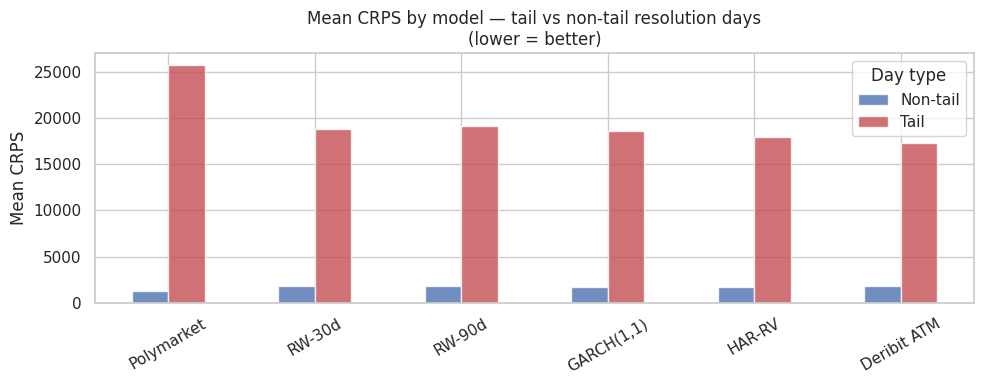

In [23]:
# ── 8d. Model performance on tail days ────────────────────────────────────────
if tail_days:
    tail_comp = eval_df[eval_df['tail']].copy()
    print(f'Tail days: {tail_comp["target_date"].nunique()} unique dates')
    print(f'Tail obs : {len(tail_comp)} rows (× TTR buckets)')
    print()
    for metric in ['LOGSCORE', 'BRIER', 'CRPS']:
        m = metric.lower()
        cols = {f'{m}_{mn}': ml for mn, ml in MODEL_LABELS.items()}
        sub  = tail_comp[[f'{m}_{mn}' for mn in MODEL_LABELS]].mean()
        sub.index = [MODEL_LABELS[mn] for mn in MODEL_LABELS]
        print(f'{metric} on tail days:')
        print(sub.round(4).to_string())
        print()

    # Bar chart: CRPS on tail vs non-tail
    crps_split = eval_df.groupby('tail')[
        [f'crps_{mn}' for mn in MODEL_NAMES]].mean()
    crps_split.index = ['Non-tail', 'Tail']
    crps_split.columns = [MODEL_LABELS[mn] for mn in MODEL_NAMES]

    fig, ax = plt.subplots(figsize=(10, 4))
    crps_split.T.plot(kind='bar', ax=ax, color=['C0','C3'], alpha=0.8)
    ax.set_title('Mean CRPS by model — tail vs non-tail resolution days\n(lower = better)')
    ax.set_ylabel('Mean CRPS'); ax.legend(title='Day type')
    ax.tick_params(axis='x', rotation=30)
    plt.tight_layout(); plt.show()


## 9. Summary of Findings

### Calibration vs benchmark models

| Metric | Finding |
|--------|---------|
| **Log-score** | Polymarket is dramatically better at every TTR horizon. At 0-4 h: PM = -0.48 vs best benchmark (Deribit ATM) = -1.91. DM tests are +4 to +5 (***) across all buckets. |
| **Brier score** | Polymarket is better at every TTR horizon (0.024 vs 0.060 at 0-4 h). DM statistics uniformly +3 to +5.5 (***). The advantage is largest close to resolution, where order-flow information dominates. |
| **CRPS - non-tail days** | On the 72 non-tail days Polymarket CRPS (1 283) is lower (better) than every benchmark (RW-30d: 1 777; HAR-RV: 1 710). |
| **CRPS - tail days** | On the 9 lower-tail days Polymarket CRPS (25 710) is higher (worse) than all benchmarks (~17 000-19 000). Lognormal models spread mass into tails naturally and are penalised less when BTC moves far outside the initial band range. |

### Diebold-Mariano tests

- **Brier loss**: All DM statistics strongly positive (*** at all horizons). Polymarket superiority is statistically significant from 0 h to 24 h before resolution.
- **Log-score loss**: Positive DM statistics (*** at all horizons). Advantage grows monotonically as TTR decreases.
- **CRPS loss**: Not significant at 8-20 h; slightly negative at 0-4 h and 20-24 h (driven by the 9 tail days).

### Edge cases: tail resolution days (9 lower-tail days, Nov 2025)

These days correspond to BTC's rapid ascent beyond the initial band range:

- **Brier and Log-score**: Polymarket still outperforms all benchmarks, because it correctly assigns higher probability to the winning tail band than a lognormal centred at the old spot price.
- **CRPS**: Benchmarks score better because the natural lognormal spread into tails happens to land closer to the realised price.
- **Probability dynamics**: Polymarket's normalised probability for the winning `<min` band grows from ~10% at 24 h to ~50% at 0-4 h, showing rapid repricing as the move becomes undeniable.
- **Calibration artefact**: The reliability diagram on tail days shows systematic over-confidence on finite bands - the one clear miscalibration in the dataset.

### Key take-aways

1. **Polymarket markets are well-calibrated** on normal days, beating every historical-vol benchmark on all proper scoring rules.
2. **Deribit ATM IV is the strongest benchmark** - incorporating option-market information substantially closes the gap vs naive historical models.
3. **HAR-RV beats GARCH(1,1)**, consistent with the established result that RV-based models outperform GARCH for multi-day forecasts.
4. **The CRPS disadvantage on tail days is structural**: band markets centred on the current price systematically underprice out-of-range moves, and CRPS is particularly sensitive to this because it integrates over the full price axis.
